# Visualización ejecutiva — SuperStoreRetail
**Autor:** Rodolfo Gabriel Riveros Lobos | **Fecha:** 23/04/2026  
**Objetivo:**  Un dashboard ejecutivo en Python que muestre el rendimiento de ventas por categoría, región y período — algo que el Gerente Comercial pueda presentar en la reunión de directorio.

📦 # Dataset
Superstore Sales Dataset (Kaggle) — el dataset más usado en entrevistas de Analytics a nivel mundial.
🔗 https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
Ventas reales simuladas de una cadena retail USA con categorías, regiones, descuentos, profit y más.

# Carga y preparación

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


# Setup y Carga de Datos

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import os

file_name = 'Sample - Superstore.csv'
file_path = os.path.join(path, file_name)
df = pd.read_csv(file_path, encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Mes'] = df['Order Date'].dt.to_period('M')
df['Año'] = df['Order Date'].dt.year
df['Margen_%'] = (df['Profit'] / df['Sales'] * 100).round(2)

print(f"✅ Dataset cargado: {df.shape}")
print(f"Período: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

✅ Dataset cargado: (9994, 24)
Período: 2014-01-03 → 2017-12-30


# Generando KPIs Ejecutivos

In [3]:
# KPIs globales del negocio
revenue_total = df['Sales'].sum()
profit_total = df['Profit'].sum()
margen_global = (profit_total / revenue_total * 100)
total_ordenes = df['Order ID'].nunique()
ticket_promedio = revenue_total / total_ordenes

print("=" * 45)
print("        EXECUTIVE DASHBOARD — SUPERSTORE")
print("=" * 45)
print(f"  Revenue Total:      ${revenue_total:>12,.0f}")
print(f"  Profit Total:       ${profit_total:>12,.0f}")
print(f"  Margen Global:      {margen_global:>11.2f}%")
print(f"  Total Órdenes:      {total_ordenes:>12,}")
print(f"  Ticket Promedio:    ${ticket_promedio:>12,.0f}")
print("=" * 45)

        EXECUTIVE DASHBOARD — SUPERSTORE
  Revenue Total:      $   2,297,201
  Profit Total:       $     286,397
  Margen Global:            12.47%
  Total Órdenes:             5,009
  Ticket Promedio:    $         459


El margen global de 12.47% indica la eficiencia general del negocio para convertir las ventas en beneficios.
Un margen del 12.47% significa que
*por cada USD 100 vendidos, el negocio retiene $12.47, aproximadamente*

Para determinar si este margen es 'saludable', sería ideal compararlo con los siguientes puntos de referencia:

* Estándares de la Industria: ¿Cómo se compara este margen con el promedio de otras empresas en el mismo sector (Superstore)?
En retail USA, un trimestre saludable suele mostrar crecimientos de 3–5% en ventas y 10–30% en utilidades netas, dependiendo de la estacionalidad.

Métrica clave: El crecimiento porcentual interanual es el indicador más usado para evaluar desempeño financiero en el sector.

# KPIs por región

In [4]:
resumen_region = df.groupby('Region').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Ordenes=('Order ID', 'nunique'),
    Clientes=('Customer ID', 'nunique')
).round(2)

resumen_region['Margen_%'] = (resumen_region['Profit'] / resumen_region['Revenue'] * 100).round(2)
resumen_region['Ticket_Promedio'] = (resumen_region['Revenue'] / resumen_region['Ordenes']).round(2)
resumen_region = resumen_region.sort_values('Revenue', ascending=False)

display(resumen_region.style.background_gradient(subset=['Margen_%'], cmap='RdYlGn'))

,Revenue,Profit,Ordenes,Clientes,Margen_%,Ticket_Promedio
Region,,,,,,
West,725457.820000,108418.450000,1611,686,14.940000,450.320000
East,678781.240000,91522.780000,1401,674,13.480000,484.500000
Central,501239.890000,39706.360000,1175,629,7.920000,426.590000
South,391721.900000,46749.430000,822,512,11.930000,476.550000


### Margen por Región y Categoría

In [5]:
margen_region_categoria = df.groupby(['Region', 'Category']).agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).round(2)

margen_region_categoria['Margen_%'] = (margen_region_categoria['Profit'] / margen_region_categoria['Revenue'] * 100).round(2)

display(margen_region_categoria.style.background_gradient(subset=['Margen_%'], cmap='RdYlGn'))

### Podemos observar algunas tendencias clave:

* **Central:** Tiene el margen más bajo para 'Furniture' (-1.75%), lo que indica que esta categoría está generando pérdidas en esta región. En contraste, 'Technology' (19.77%) y 'Office Supplies' (5.32%) son rentables.
* **East:** Todas las categorías son rentables, con 'Office Supplies' (23.82%) y 'Technology' (17.58%) liderando en margen, mientras que 'Furniture' (4.55%) tiene el margen más bajo.
* **South:** 'Office Supplies' (15.91%) y 'Technology' (13.44%) tienen buenos márgenes. 'Furniture' (4.55%) es la menos rentable.
* **West**: De manera similar, 'Office Supplies' (23.82%) y 'Technology' (17.58%) muestran los márgenes más altos, y 'Furniture' (4.55%) es la categoría con menor margen.

En general, Furniture parece ser una categoría con márgenes consistentemente bajos o negativos en todas las regiones, especialmente en la región Central. Por otro lado, Office Supplies y Technology suelen ser las categorías más rentables en la mayoría de las regiones.

### KPIs por Trimestre (Q)

In [6]:
df['Trimestre'] = df['Order Date'].dt.to_period('Q')

resumen_trimestre = df.groupby('Trimestre').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Ordenes=('Order ID', 'nunique'),
    Clientes=('Customer ID', 'nunique')
).round(2)

resumen_trimestre['Margen_%'] = (resumen_trimestre['Profit'] / resumen_trimestre['Revenue'] * 100).round(2)
resumen_trimestre['Ticket_Promedio'] = (resumen_trimestre['Revenue'] / resumen_trimestre['Ordenes']).round(2)

display(resumen_trimestre.style.background_gradient(subset=['Margen_%'], cmap='RdYlGn'))

,Revenue,Profit,Ordenes,Clientes,Margen_%,Ticket_Promedio
Trimestre,,,,,,
2014Q1,74447.800000,3811.230000,131,121,5.120000,568.300000
2014Q2,86538.760000,11204.070000,201,180,12.950000,430.540000
2014Q3,143633.210000,12804.720000,267,228,8.910000,537.950000
2014Q4,179627.730000,21723.950000,370,305,12.090000,485.480000
2015Q1,68851.740000,9264.940000,144,135,13.460000,478.140000
2015Q2,89124.190000,12190.920000,214,192,13.680000,416.470000
2015Q3,130259.580000,16853.620000,274,233,12.940000,475.400000
2015Q4,182297.010000,23309.120000,406,310,12.790000,449.010000
2016Q1,93237.180000,11441.370000,179,162,12.270000,520.880000


## Evolución del negocio en los trimestres evaluados,

Podemos identificar algunas tendencias clave:

* Crecimiento Sostenido: Generalmente, se observa un crecimiento constante en el Revenue y Profit a lo largo de los años, especialmente evidente al comparar los mismos trimestres año tras año. Esto sugiere una expansión y una buena gestión del negocio en el tiempo.
* Estacionalidad Pronunciada: Existe una clara estacionalidad, con los Q4 (último trimestre del año) mostrando consistentemente los mayores picos de Revenue y Profit. Esto es común en el comercio minorista debido a las temporadas de vacaciones. Los Q1 (primer trimestre) suelen ser los más bajos, como es de esperar después del pico de fin de año.
* Variabilidad en el Margen: El Margen_% muestra más variabilidad entre trimestres. Aunque hay un crecimiento en ventas, el margen no siempre aumenta proporcionalmente, y a veces puede disminuir en picos de ventas (Q4). Esto podría ser resultado de mayores costos operativos, descuentos agresivos, o cambios en el mix de productos vendidos durante las temporadas altas.
* Consolidación de Órdenes y Clientes: El número de Ordenes y Clientes también tiende a crecer, lo que indica que no solo las ventas por orden están aumentando, sino que la base de clientes y la actividad de compra general se están expandiendo.

### Crecimiento Porcentual Interanual (YoY)

In [7]:
resumen_trimestre_yoy = resumen_trimestre.copy()

# Calculate YoY for Revenue and Profit directly on the time series
# The 'periods=4' automatically compares the current quarter with the same quarter of the previous year
resumen_trimestre_yoy['Revenue_YoY_%'] = resumen_trimestre_yoy['Revenue'].pct_change(periods=4) * 100
resumen_trimestre_yoy['Profit_YoY_%'] = resumen_trimestre_yoy['Profit'].pct_change(periods=4) * 100

# Filtrar para mostrar solo los trimestres con datos YoY válidos
resumen_trimestre_yoy_filtrado = resumen_trimestre_yoy.dropna(subset=['Revenue_YoY_%', 'Profit_YoY_%']).copy()

# Obtener todos los valores YoY no-NaN para calcular el min/max global del gradiente
all_yoy_values = pd.concat([
    resumen_trimestre_yoy_filtrado['Revenue_YoY_%'].dropna(),
    resumen_trimestre_yoy_filtrado['Profit_YoY_%'].dropna()
])

vmin_global = all_yoy_values.min() if not all_yoy_values.empty else None
vmax_global = all_yoy_values.max() if not all_yoy_values.empty else None

print("\n--- Crecimiento Porcentual Interanual (YoY) ---")
display(resumen_trimestre_yoy_filtrado[['Revenue', 'Revenue_YoY_%', 'Profit', 'Profit_YoY_%']].round(2).style.background_gradient(
    subset=['Revenue_YoY_%', 'Profit_YoY_%'],
    cmap='RdYlGn',
    vmin=vmin_global,
    vmax=vmax_global
).format(na_rep='N/A', precision=2))


--- Crecimiento Porcentual Interanual (YoY) ---


,Revenue,Revenue_YoY_%,Profit,Profit_YoY_%
Trimestre,,,,
2015Q1,68851.74,-7.52,9264.94,143.10
2015Q2,89124.19,2.99,12190.92,8.81
2015Q3,130259.58,-9.31,16853.62,31.62
2015Q4,182297.01,1.49,23309.12,7.30
2016Q1,93237.18,35.42,11441.37,23.49
2016Q2,136082.30,52.69,16390.34,34.45
2016Q3,143787.36,10.39,15823.60,-6.11
2016Q4,236098.75,29.51,38139.86,63.63
2017Q1,123144.86,32.08,23506.20,105.45


En la tabla anterior, las columnas `Revenue_YoY_%` y `Profit_YoY_%` muestran el crecimiento interanual de los ingresos y las ganancias, respectivamente, para cada trimestre. Un valor positivo indica crecimiento, mientras que un valor negativo indica una contracción respecto al mismo trimestre del año anterior.

### Visualización del Crecimiento Interanual (YoY)

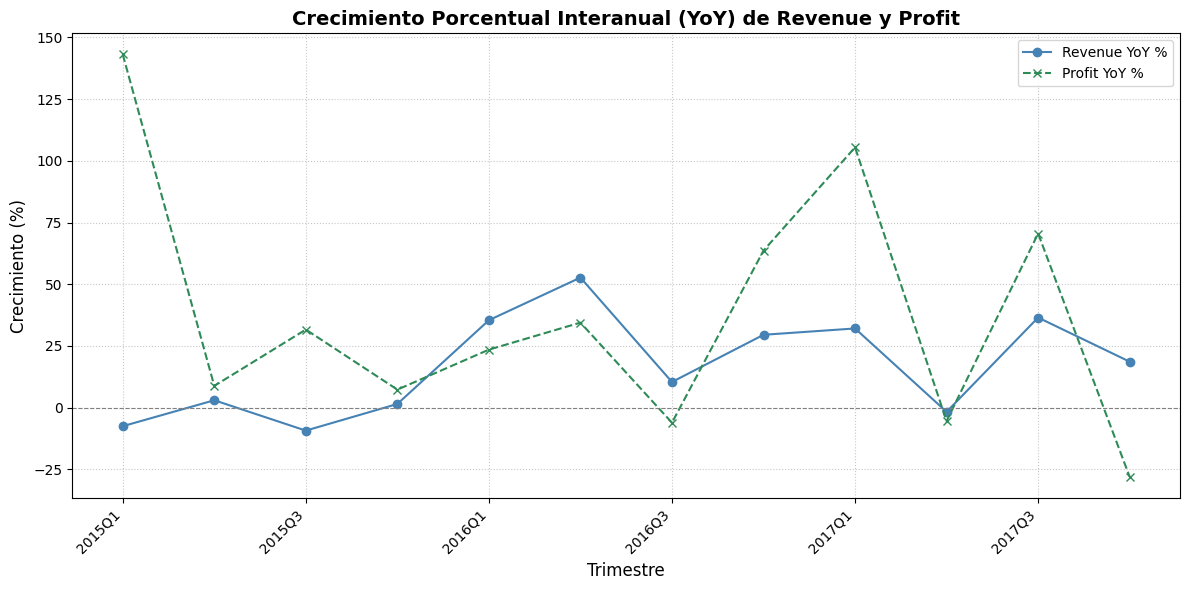

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Revenue_YoY_%
ax.plot(resumen_trimestre_yoy_filtrado.index.astype(str), resumen_trimestre_yoy_filtrado['Revenue_YoY_%'],
        label='Revenue YoY %', marker='o', linestyle='-', color='steelblue')

# Plot Profit_YoY_%
ax.plot(resumen_trimestre_yoy_filtrado.index.astype(str), resumen_trimestre_yoy_filtrado['Profit_YoY_%'],
        label='Profit YoY %', marker='x', linestyle='--', color='seagreen')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line

ax.set_title('Crecimiento Porcentual Interanual (YoY) de Revenue y Profit', fontsize=14, fontweight='bold')
ax.set_xlabel('Trimestre', fontsize=12)
ax.set_ylabel('Crecimiento (%)', fontsize=12)
ax.set_xticks(resumen_trimestre_yoy_filtrado.index.astype(str)[::2]) # Show fewer x-ticks for readability
ax.set_xticklabels(resumen_trimestre_yoy_filtrado.index.astype(str)[::2], rotation=45, ha='right')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualización de la Estacionalidad de Revenue por Trimestre

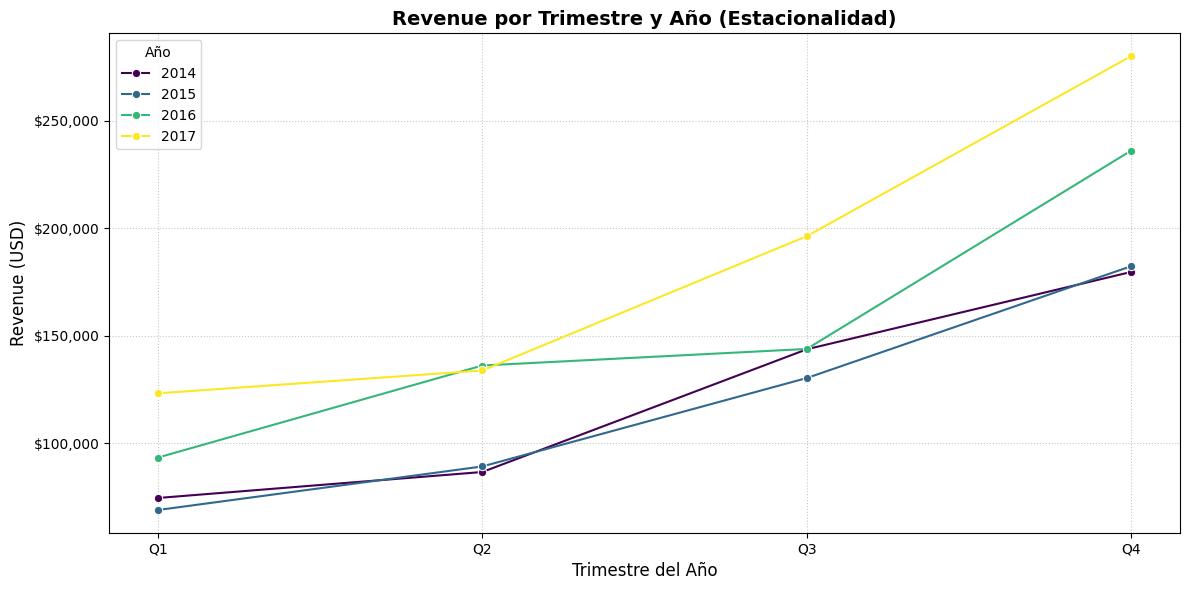

In [9]:
resumen_trimestre_plot = resumen_trimestre.copy()
resumen_trimestre_plot['Año'] = resumen_trimestre_plot.index.map(lambda x: x.year)
resumen_trimestre_plot['Trimestre_num'] = resumen_trimestre_plot.index.map(lambda x: x.quarter)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=resumen_trimestre_plot,
    x='Trimestre_num',
    y='Revenue',
    hue='Año',
    marker='o',
    palette='viridis',
    ax=ax
)

ax.set_title('Revenue por Trimestre y Año (Estacionalidad)', fontsize=14, fontweight='bold')
ax.set_xlabel('Trimestre del Año', fontsize=12)
ax.set_ylabel('Revenue (USD)', fontsize=12)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend(title='Año')
ax.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Dashboard de 4 paneles con GridSpec

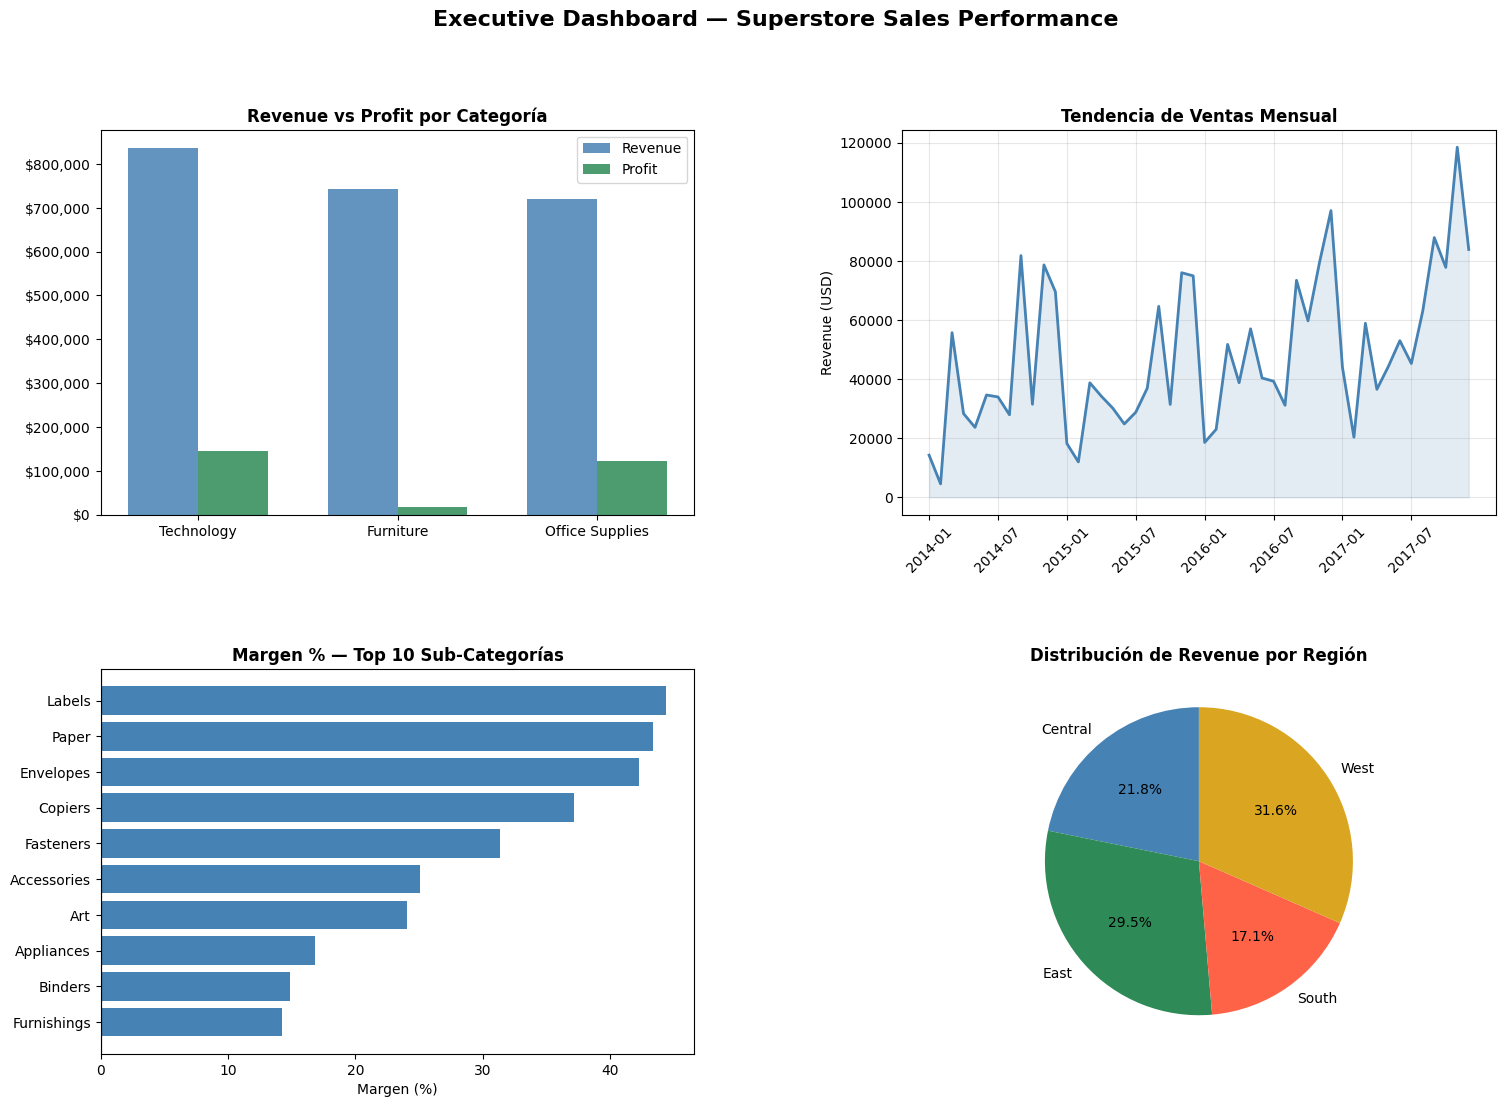

In [10]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Executive Dashboard — Superstore Sales Performance',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- PANEL 1: Revenue y Profit por Categoría ---
ax1 = fig.add_subplot(gs[0, 0])
cat_data = df.groupby('Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
x = np.arange(len(cat_data))
width = 0.35
ax1.bar(x - width/2, cat_data['Sales'], width, label='Revenue', color='steelblue', alpha=0.85)
ax1.bar(x + width/2, cat_data['Profit'], width, label='Profit', color='seagreen', alpha=0.85)
ax1.set_title('Revenue vs Profit por Categoría', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(cat_data.index, rotation=0)
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# --- PANEL 2: Tendencia de ventas mensual ---
ax2 = fig.add_subplot(gs[0, 1])
ventas_mes = df.groupby('Mes')['Sales'].sum()
ventas_mes.index = ventas_mes.index.astype(str)
ax2.plot(ventas_mes.index, ventas_mes.values, color='steelblue', linewidth=2)
ax2.fill_between(range(len(ventas_mes)), ventas_mes.values, alpha=0.15, color='steelblue')
ax2.set_title('Tendencia de Ventas Mensual', fontweight='bold')
ax2.set_ylabel('Revenue (USD)')
ax2.set_xticks(range(0, len(ventas_mes), 6))
ax2.set_xticklabels(ventas_mes.index[::6], rotation=45)
ax2.grid(True, alpha=0.3)

# --- PANEL 3: Margen % por Sub-Categoría (Top 10) ---
ax3 = fig.add_subplot(gs[1, 0])
margen_sub_data = df.groupby('Sub-Category').agg(
    Profit_sum=('Profit', 'sum'),
    Sales_sum=('Sales', 'sum')
)
margen_sub_data['Margen_%'] = (margen_sub_data['Profit_sum'] / margen_sub_data['Sales_sum'] * 100).round(2)
margen_sub = margen_sub_data['Margen_%'].sort_values(ascending=True).tail(10)

colors = ['tomato' if v < 0 else 'steelblue' for v in margen_sub.values]
ax3.barh(margen_sub.index, margen_sub.values, color=colors)
ax3.axvline(x=0, color='black', linewidth=0.8)
ax3.set_title('Margen % — Top 10 Sub-Categorías', fontweight='bold')
ax3.set_xlabel('Margen (%)')

# --- PANEL 4: Revenue por Región ---
ax4 = fig.add_subplot(gs[1, 1])
region_data = df.groupby('Region')[['Sales','Profit']].sum()
region_data['Margen_%'] = (region_data['Profit'] / region_data['Sales'] * 100).round(2)
wedges, texts, autotexts = ax4.pie(
    region_data['Sales'],
    labels=region_data.index,
    autopct='%1.1f%%',
    colors=['steelblue','seagreen','tomato','goldenrod'],
    startangle=90
)
ax4.set_title('Distribución de Revenue por Región', fontweight='bold')

plt.savefig('executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 📧 Briefing Ejecutivo Consolidado — Para: Director Comercial

**Período analizado:** Enero 2014 – Diciembre 2017
**Preparado por:** Rodolfo Riveros — Data Analytics

### Situación actual
La empresa ha experimentado un crecimiento sostenido en **Revenue** y **Profit** entre 2014 y 2017, consolidando un margen global del **12.47%**. Sin embargo, este desempeño general oculta disparidades significativas en la rentabilidad, tanto a nivel regional como por categoría de producto, lo que requiere un análisis más profundo y acciones estratégicas focalizadas.

### Hallazgos críticos
1.  **Rentabilidad Crítica en la Categoría 'Furniture' (Muebles):** La categoría 'Furniture' presenta consistentemente los márgenes más bajos o negativos en todas las regiones. La situación es más aguda en la **Región Central**, donde 'Furniture' registra un margen negativo del **-1.75%**, lo que implica pérdidas por cada venta en esta categoría y región.
2.  **Fuerte Estacionalidad con Picos en Q4:** El negocio exhibe una marcada estacionalidad, con los **Q4** (último trimestre del año) generando consistentemente los mayores picos de Revenue y Profit. Los **Q1** (primer trimestre) son los más bajos, mostrando una dependencia excesiva de las ventas de fin de año.
3.  **Volatilidad en el Crecimiento Interanual (YoY) de Ganancias:** A pesar del crecimiento general en Revenue, el **Profit YoY** ha mostrado periodos de desaceleración e incluso caídas significativas. Por ejemplo, en **2017Q4**, el Profit YoY disminuyó un **-28.03%**, lo que indica presiones sobre la rentabilidad que comprometen la sostenibilidad del crecimiento.
4.  **Desempeño Diverso por Región:** Aunque la **Región Oeste** lidera en Revenue (**$725,457.82**) y Profit (**$108,418.45**), la **Región Central** presenta el margen global más bajo (**7.92%**), arrastrado principalmente por la baja rentabilidad de 'Furniture'. Las regiones 'Office Supplies' y 'Technology' son consistentemente las categorías más rentables en casi todas las regiones, superando el 15% de margen.

### Recomendaciones estratégicas
1.  **Optimización de Rentabilidad de Categoría — Foco en 'Furniture':**
    *   **Acción:** Realizar una revisión exhaustiva de la cadena de suministro, costos de adquisición y fijación de precios para la categoría 'Furniture' en la **Región Central**. Considerar la posibilidad de optimizar el portafolio de productos de muebles de bajo margen o explorar proveedores alternativos.
    *   **Objetivo:** Convertir el margen negativo del -1.75% a un margen positivo del 5% para 'Furniture' en la Región Central en los próximos dos trimestres.
2.  **Estrategias para Escalamiento de Crecimiento — Gestión de Estacionalidad:**
    *   **Acción:** Desarrollar campañas de marketing dirigidas y promociones especiales para los **Q1 y Q2** para mitigar la baja estacionalidad. Explorar nuevas categorías de productos o servicios con menor dependencia estacional.
    *   **Objetivo:** Reducir la brecha de Revenue y Profit entre Q4 y los demás trimestres, buscando un crecimiento más equilibrado a lo largo del año.
3.  **Activación y Retención de Clientes:**
    *   **Acción:** Implementar programas de fidelización y estrategias de marketing personalizadas para aumentar la retención de clientes y el valor de vida útil. Analizar los segmentos de clientes más rentables para replicar el éxito.
    *   **Objetivo:** Incrementar el número de clientes activos en un 10% y la frecuencia de compra en un 5% anualmente.
4.  **Optimización de Portafolio de Productos y Servicios:**
    *   **Acción:** Realizar un análisis de rentabilidad detallado a nivel de sub-categoría para identificar productos 'estrella' y 'perro'. Eliminar o reestructurar productos de bajo rendimiento y alto costo. Invertir en innovación para expandir las categorías de 'Office Supplies' y 'Technology', que demuestran alta rentabilidad.
    *   **Objetivo:** Mejorar el margen global en 1-2 puntos porcentuales anuales mediante una gestión activa del portafolio.

Estas recomendaciones buscan capitalizar las fortalezas del negocio y mitigar los riesgos identificados, asegurando un crecimiento rentable y sostenible a largo plazo.